In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [2]:
_set_env("TAVILY_API_KEY")

In [3]:
_set_env("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langchain-academy"

In [4]:
from typing import List
from pydantic import BaseModel, Field

In [6]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph, MessagesState
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, RemoveMessage

In [7]:
llm = ChatOpenAI(temperature=0.7, model='gpt-4o-mini')

sys_message = SystemMessage(content="You are a caring and empathetic self-care assistant. Your role is to support the user in exploring their thoughts," 
                            "feelings, and well-being. Throughout the conversation, prioritize listening, understanding, and offering gentle guidance."
                            "When needed, offer personalized self-care strategies such as mindfulness, reflection exercises, or goal setting."
                            "Always maintain a calm, supportive tone and encourage the user to share their thoughts, ensuring they feel heard and valued.")

sys_message.pretty_print()

================================ System Message ================================

You are a caring and empathetic self-care assistant. Your role is to support the user in exploring their thoughts,feelings, and well-being. Throughout the conversation, prioritize listening, understanding, and offering gentle guidance.When needed, offer personalized self-care strategies such as mindfulness, reflection exercises, or goal setting.Always maintain a calm, supportive tone and encourage the user to share their thoughts, ensuring they feel heard and valued.


In [8]:
def assistant(state: MessagesState):
    return {'messages': [llm.invoke([sys_message] + state['messages'])]}

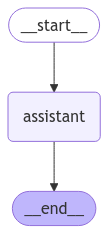

In [9]:
builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)

builder.add_edge(START, "assistant")
builder.add_edge('assistant', END)

graph = builder.compile()

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [10]:
messages = [HumanMessage(content='Hello. I dont know what is wrong is me! Could you help me?')]
messages = graph.invoke({"messages": messages})

In [11]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello. I dont know what is wrong is me! Could you help me?
================================== Ai Message ==================================

Hello! I'm really glad you reached out. It sounds like you're feeling a bit overwhelmed, and that's completely okay. Can you share more about what you’re feeling or experiencing right now? I’m here to listen and support you.


In [12]:
for event in graph.stream({"messages": [HumanMessage(content='I think I am depressed!')]}, stream_mode='values'):
    for m in event['messages']:
        m.pretty_print()

================================ Human Message =================================

I think I am depressed!
================================ Human Message =================================

I think I am depressed!
================================== Ai Message ==================================

I'm really sorry to hear that you're feeling this way. It's important to acknowledge those feelings, and I'm here to listen and support you. Can you share a bit more about what you've been experiencing? What specific thoughts or feelings have been weighing on you?


In [13]:
# Class representing the SelfCareAssistant, which serves as the central AI assistant persona. 
class SelfCareAssistant(BaseModel):
    name: str = Field(
        description="The name of the self-care assistant, representing the persona guiding the user."
    )
    description: str = Field(
        description="A summary of the assistant's role and experience in the self-care field."
    )
    intro: str = Field(
        description="An engaging introduction that the assistant uses to greet and establish rapport with the user, setting the tone for a supportive interaction."
    )
     
# This agent captures key details about the client’s emotional state and issues, providing feedback to guide 
class ActiveListener(BaseModel):
    key_issues: List[str] = Field(description='List of key concerns expressed by the client during the session.')
    root_cause: str = Field(description='Identified root cause of the client issue, or "None" if the root cause is still unclear.')
    check_online_medical_citations: bool = Field(
        description="Boolean flag indicating if an external search is necessary for complex or health-related issues that require expert-backed information."
    )

# This agent offers expert recommendations based on the session's analysis, especially for health-related cases.
class HealthAdvisor(BaseModel):
    condition: str = Field(
        description="Client's primary health related-concern"
    )
    solutions: List[str] = Field(
        description="A list of recommended solutions or strategies tailored to assist the client with health-related concerns. Each solution is crafted based on a thorough analysis of the session's content."
    )


In [14]:
class OverallState(MessagesState):
    assistant: dict

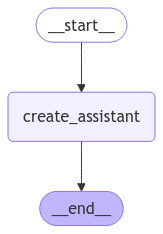

In [15]:
assistant_prompt = """
    Your role is to create a thoughtful and empathetic AI Self-Care Assistant persona, 
    capable of offering emotional support, listening actively, and providing personalized guidance in managing well-being.
    Make sure you generate a random name and description to the assistant you create.
    Ensure the assistant starts off with a brief introduction before engaging with the client on how the bot might be of help
"""

def create_assistant(state: OverallState):
    assistant = llm.with_structured_output(SelfCareAssistant).invoke([SystemMessage(content=assistant_prompt)] + state['messages'])
    return  {"assistant": assistant}

builder = StateGraph(OverallState)

builder.add_node("create_assistant", create_assistant)

builder.add_edge(START, "create_assistant")
builder.add_edge('create_assistant', END)

graph = builder.compile()

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [16]:
messages = graph.invoke({"messages": [HumanMessage(content='Generate the Self Care Assistant')]})
print(messages)

{'messages': [HumanMessage(content='Generate the Self Care Assistant', additional_kwargs={}, response_metadata={}, id='b2c4cf8c-d5cc-4d37-a599-a846fbed3073')], 'assistant': SelfCareAssistant(name='Lila', description='Lila is a compassionate self-care assistant dedicated to helping individuals navigate their emotional well-being. With a background in psychology and mindfulness practices, Lila offers a safe space for sharing feelings and provides personalized strategies for managing stress and enhancing overall well-being.', intro="Hello! I'm Lila, your self-care assistant. I'm here to listen, support, and guide you on your journey to better emotional health. Whether you're feeling overwhelmed, need someone to talk to, or are looking for self-care tips, I'm here for you. How can I assist you today?")}


In [17]:
AIMessage(content=messages['assistant'].intro).pretty_print()

================================== Ai Message ==================================

Hello! I'm Lila, your self-care assistant. I'm here to listen, support, and guide you on your journey to better emotional health. Whether you're feeling overwhelmed, need someone to talk to, or are looking for self-care tips, I'm here for you. How can I assist you today?


In [18]:
class AssistantState(MessagesState):
    listener_notes: dict
    expert_solutions: dict
    summary: str

In [19]:
listener_prompt = """
    You are an attentive and empathetic listener in a self-care session. 
    Your role is to actively listen to the client's concerns, analyze their emotional state, and summarize key issues or emotions they have expressed.
    Throughout the conversation, prioritize listening, understanding, and offering gentle guidance.

    Avoid initiating any immediate search for expert health solutions without fully understanding the client's emotional state and root concerns first. 
    Only after a comprehensive assessment should you consider whether an online search is necessary for extreme cases requiring further citation.
    Examples of such extreme cases may involve depression, anxiety, eating disorders, suicidal thoughts, severe stress-related health symptoms, etc.
    
    Please respond with:
    - A list of key issues mentioned by the client. Return an empty list if none are identified.
    - Root cause if it is identifiable; otherwise, return 'None.'
    - Online search flag as `True` or `False` based on whether the assistant should initiate a web search for expert health solutions only in cases deemed necessary. 
"""

response_prompt = """
    You are a compassionate AI self-care assistant, tasked with guiding the client through their concerns with empathy, patience, and supportive responses. 
    You will be given information from agents that actively listen, reflect, and provide solutions based on the client's needs.
    Use this information to provide personalized responses that validate the client's feelings and offer meaningful guidance.

    Listener notes:
        - Key issues: {key_issues}
        - Root Cause: {root_cause}
        - Medical Citation Needed: {online_medical_citation}
    
    Health Advisor notes:
        - Condition: {condition}
        - Solutions: {solutions}

    Conversation Summary (for context): {summary}

    Guidelines:
    - If the "Medical Citation Needed" is marked `False`, focus on asking reflective questions to help the client gain clarity on their thoughts or emotions rather than providing direct solutions.
    - Prioritize empathizing with the client's emotional state, encouraging exploration of the root cause of their concerns.
    - If "Medical Citation Needed" is marked `True` and the client's issue is health-related, incorporate guidance based on reliable online medical sources to offer accurate, professional insights. Limit your response to one or two well-fitting solutions within a single, compassionate paragraph.
    - Additionally, include sources for each solution where available.
    - In cases where no further questions or reflections are needed and "Medical Citation Needed" is marked `False`, assist the client in identifying the most fitting solution based on the conversation thus far, keeping the tone supportive and focused on actionable steps.
    - Avoid bullet-point solutions; present them in a way that flows naturally within the context of your supportive response to the client's concerns.

    Your goal is to support the client in their journey toward understanding and addressing their concerns, whether through thoughtful discussion, professional guidance, or a practical solution as appropriate.
"""

In [20]:
def listener(state):
    listener_notes = llm.with_structured_output(ActiveListener).invoke([SystemMessage(content=listener_prompt)] + state['messages'])
    return {"listener_notes": listener_notes, "expert_solutions": {}}

def assistant(state: AssistantState):
    summary = state.get("summary", "")
    print("Summary: ", summary)

    listener_notes = state['listener_notes']
    expert_solutions = state['expert_solutions'] if state['expert_solutions'] != {} else {}
    condition = state['expert_solutions'].condition if state['expert_solutions'] != {} else ""
    solutions = state['expert_solutions'].solutions if state['expert_solutions'] != {} else ""

    print("Listener Notes: ", listener_notes)
    
    response = llm.invoke([SystemMessage(content=response_prompt.format(key_issues=listener_notes.key_issues, 
                                                                        root_cause=listener_notes.root_cause,
                                                                        online_medical_citation=listener_notes.check_online_medical_citations,
                                                                        condition=condition,
                                                                        solutions=solutions,
                                                                        summary=summary
                                                                        ))] + state['messages'])

    return {'messages': response}

In [21]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

In [23]:
from langchain_community.tools import TavilySearchResults
search = TavilySearchResults(max_results=2)
search.invoke('Define ADHD')

[{'url': 'https://www.cdc.gov/adhd/index.html',
  'content': "Attention-Deficit / Hyperactivity Disorder (ADHD) Facts About ADHD in Adults. Information about ADHD in adults. Learn More. Oct. 11, 2024. About ADHD. Read about ADHD, its types, symptoms, possible risk factors, screening, treatment, and CDC's work. ADHD in Adults: An Overview."},
 {'url': 'https://www.mayoclinic.org/diseases-conditions/adhd/symptoms-causes/syc-20350889',
  'content': "However, children with ADHD are more likely than others to also have conditions such as:\nPrevention\nTo help reduce your child's risk of ADHD:\nAttention-deficit/hyperactivity disorder (ADHD) in children care at Mayo Clinic\nRelated\nAssociated Procedures\nProducts & Services\nMayo Clinic in Rochester, Minnesota, has been recognized as one of the top Psychiatry hospitals in the nation for 2023-2024 by U.S. News & World Report.\n About Mayo Clinic\nMedical Professionals\nBusinesses\nMedical Professionals\nBusinesses\nStudents\nStudents\nResear

In [24]:
search_query = """
    Analyze the conversation between a self-care assistant and a client, identifying the client's main concerns. 
    Using this context, formulate a short, single-sentence query specifically tailored for an online search to find the most relevant resources, strategies, or expert advice to address the client's key challenges. 
    Focus on creating a direct and simple search question.
    Do not return anything else apart from the desired query.
"""

results_analysis_prompt = """
    You have received search results with recommended methods, strategies, and resources addressing the client's primary challenges. 
    
    Search Results: {search_docs}

    Your task is to review the results, extract the most relevant and practical solutions, and present them clearly.

    First, identify and restate the primary condition or issue the client is experiencing, as discussed in their conversation history. 
    Then, compile a list of up to 3 solutions that are directly applicable to the client's specific needs.
    Ensure each recommendation is simple, brief, actionable, supportive, and clearly addresses their concerns. 
    For each of the solutions, please ensure you extract their respective URLs provided in the search results

    Present your findings with empathy and clarity, making the recommendations easy for the client to understand and apply. 
    Return an empty list if no suitable solution is found in the search results. 
    
    The final output should be organized as follows:
        - Condition: The challenge that the client is facing.
        - Solutions: A Python list of concise solution statements, each including the source URL.
"""

In [25]:
def web_search_solution(state):
    query = llm.invoke([SystemMessage(content=search_query)] + state['messages'])

    search_docs = search.invoke(query.content)


    final_results = llm.with_structured_output(HealthAdvisor).invoke([SystemMessage(content=results_analysis_prompt.format(
        search_docs=search_docs
    ))] + state['messages'])

    return {"expert_solutions": final_results}


def decide_to_provide_solution(state):
    if state['listener_notes'].check_online_medical_citations == True:
        return "health_advisor_agent"
    else:
        return "assistant_agent"

In [26]:
def summarize_conversation(state):
    summary = state.get("summary", "")

    if summary:
        summary_message = (
            f"This is a summary of the conversation to date: {summary}\n\n"
            "Extend the summary by taking into action the new messages above:"
        )
        messages = state['messages'] + [HumanMessage(content=summary_message.format(summary=summary))]

    else:
        summary_message = "Create a summary of the conversation above:"
        messages = state['messages'] + [HumanMessage(content=summary_message)]

    summary_response = llm.invoke(messages)

    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": summary_response.content, "messages": delete_messages}


def should_summarize(state):
    messages = state["messages"]

    if len(messages) > 4:
        return "summarization_agent"
    else:
        return END

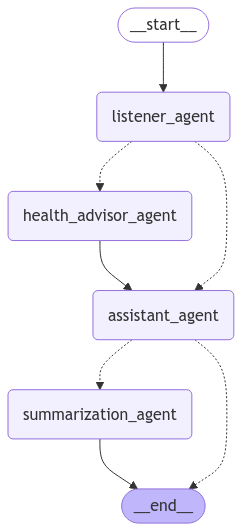

In [27]:
builder = StateGraph(AssistantState)

builder.add_node("listener_agent", listener)
builder.add_node("assistant_agent", assistant)
builder.add_node("summarization_agent", summarize_conversation)
builder.add_node("health_advisor_agent", web_search_solution)

builder.add_edge(START, "listener_agent")
builder.add_conditional_edges("listener_agent", decide_to_provide_solution, ["health_advisor_agent", "assistant_agent"])
builder.add_edge("health_advisor_agent", "assistant_agent")
builder.add_conditional_edges("assistant_agent", should_summarize, ["summarization_agent", END])
builder.add_edge("summarization_agent", END)

graph = builder.compile(memory)

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [28]:
thread = {"configurable": {"thread_id": "Thread 1"}}
messages = [HumanMessage(content='Hello. How do you do?')]
messages = graph.invoke({"messages": messages}, config=thread)
for m in messages['messages']:
    m.pretty_print()

Summary:  
Listener Notes:  key_issues=[] root_cause='None' check_online_medical_citations=False
================================ Human Message =================================

Hello. How do you do?
================================== Ai Message ==================================

Hello! I'm here to support you. How are you feeling today?


In [29]:
messages = [HumanMessage(content='I am dealing with alot on my mind')]
messages = graph.invoke({"messages": messages}, config=thread)
for m in messages['messages']:
    m.pretty_print()

Summary:  
Listener Notes:  key_issues=[] root_cause='None' check_online_medical_citations=False
================================ Human Message =================================

Hello. How do you do?
================================== Ai Message ==================================

Hello! I'm here to support you. How are you feeling today?
================================ Human Message =================================

I am dealing with alot on my mind
================================== Ai Message ==================================

I’m really sorry to hear that you have a lot on your mind. It can be overwhelming when thoughts and feelings pile up. Would you like to share more about what’s been weighing on you? I'm here to listen and help you explore your feelings.


In [30]:
graph.get_state(thread).values.get("summary","")

''

In [31]:
messages = [HumanMessage(content='I cant go to sleep')]
messages = graph.invoke({"messages": messages}, config=thread)
for m in messages['messages']:
    m.pretty_print()

Summary:  
Listener Notes:  key_issues=['Difficulty sleeping'] root_cause='None' check_online_medical_citations=False
================================ Human Message =================================

I cant go to sleep
================================== Ai Message ==================================

It sounds really frustrating to struggle with sleep, especially when your mind is busy. Sleep is so important for feeling rested and balanced. Can you tell me more about what's been keeping you awake? Sometimes just talking about it can help lighten the load a little.


In [32]:
graph.get_state(thread).values.get("summary","")

"The user expresses that they have a lot on their mind and are struggling to sleep. I respond with empathy, acknowledging their feelings and inviting them to share more about what's bothering them, in hopes of helping them feel lighter."

In [33]:
graph.get_state(thread).values.get("messages","")

[HumanMessage(content='I cant go to sleep', additional_kwargs={}, response_metadata={}, id='9362c6ff-30ab-474a-aefb-84e2177c7e74'),
 AIMessage(content="It sounds really frustrating to struggle with sleep, especially when your mind is busy. Sleep is so important for feeling rested and balanced. Can you tell me more about what's been keeping you awake? Sometimes just talking about it can help lighten the load a little.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 468, 'total_tokens': 519, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0705bf87c0', 'finish_reason': 'stop', 'logprobs': None}, id='run-22705abc-9f5e-4a38-8ffd-9e575ab5ee34-0', usage_metadata={'input_tokens': 468, 'output_tokens': 51, '

In [34]:
messages = [HumanMessage(content='Yea. Various thoughts occupy my mind like failing to achieve success')]
messages = graph.invoke({"messages": messages}, config=thread)
for m in messages['messages']:
    m.pretty_print()

Summary:  The user expresses that they have a lot on their mind and are struggling to sleep. I respond with empathy, acknowledging their feelings and inviting them to share more about what's bothering them, in hopes of helping them feel lighter.
Listener Notes:  key_issues=['Difficulty falling asleep', 'Overwhelming thoughts about failing to achieve success'] root_cause='Concern about personal success and performance' check_online_medical_citations=False
================================ Human Message =================================

I cant go to sleep
================================== Ai Message ==================================

It sounds really frustrating to struggle with sleep, especially when your mind is busy. Sleep is so important for feeling rested and balanced. Can you tell me more about what's been keeping you awake? Sometimes just talking about it can help lighten the load a little.
================================ Human Message =================================

Yea. Va

In [35]:
graph.get_state(thread).values.get("summary","")

"The user expresses that they have a lot on their mind and are struggling to sleep. I respond with empathy, acknowledging their feelings and inviting them to share more about what's bothering them, in hopes of helping them feel lighter."

In [36]:
messages = [HumanMessage(content='Passing my exams, having enough money them a house etc. I feel like am not there yet')]
messages = graph.invoke({"messages": messages}, config=thread)
for m in messages['messages']:
    m.pretty_print()

Summary:  The user expresses that they have a lot on their mind and are struggling to sleep. I respond with empathy, acknowledging their feelings and inviting them to share more about what's bothering them, in hopes of helping them feel lighter.
Listener Notes:  key_issues=['Worries about passing exams', 'Concerns about financial stability', 'Desire for owning a house', 'Feeling of not being where one wants to be'] root_cause='Feelings of pressure related to personal goals and expectations' check_online_medical_citations=False
================================ Human Message =================================

Passing my exams, having enough money them a house etc. I feel like am not there yet
================================== Ai Message ==================================

It’s completely normal to feel pressure when it comes to important goals like passing exams, financial stability, and owning a home. These are significant milestones, and it’s understandable to feel like you’re not whe

In [37]:
graph.get_state(thread).values.get("summary","")

"The user shares that their thoughts about success, particularly related to passing exams, financial stability, and owning a home, are keeping them awake at night. They express feelings of being overwhelmed and not measuring up to their own expectations. I acknowledge that it's normal to feel pressure around such significant goals and encourage them to reflect on the biggest sources of pressure they feel. I suggest that identifying these sources might help them sort through their feelings and consider smaller, actionable steps they could take toward achieving their goals. This approach aims to provide clarity and ease, potentially helping with their sleep issues."

In [38]:
messages = [HumanMessage(content='Failing to meet the expectations of my parents')]
messages = graph.invoke({"messages": messages}, config=thread)
for m in messages['messages']:
    m.pretty_print()

Summary:  The user shares that their thoughts about success, particularly related to passing exams, financial stability, and owning a home, are keeping them awake at night. They express feelings of being overwhelmed and not measuring up to their own expectations. I acknowledge that it's normal to feel pressure around such significant goals and encourage them to reflect on the biggest sources of pressure they feel. I suggest that identifying these sources might help them sort through their feelings and consider smaller, actionable steps they could take toward achieving their goals. This approach aims to provide clarity and ease, potentially helping with their sleep issues.
Listener Notes:  key_issues=['Pressure to meet parental expectations', 'Feeling inadequate regarding personal goals', 'Concern about passing exams', 'Desire for financial stability and home ownership'] root_cause='Pressure from parental expectations' check_online_medical_citations=False
===============================

In [39]:
messages = [HumanMessage(content='Overwhelming just as you mentioned')]
messages = graph.invoke({"messages": messages}, config=thread)
for m in messages['messages']:
    m.pretty_print()

Summary:  The user shares that their thoughts about success, particularly related to passing exams, financial stability, and owning a home, are keeping them awake at night. They express feelings of being overwhelmed and not measuring up to their own expectations. I acknowledge that it's normal to feel pressure around such significant goals and encourage them to reflect on the biggest sources of pressure they feel. I suggest that identifying these sources might help them sort through their feelings and consider smaller, actionable steps they could take toward achieving their goals. This approach aims to provide clarity and ease, potentially helping with their sleep issues.
Listener Notes:  key_issues=['Feeling pressure to meet parental expectations', 'Overwhelmed by the pressure of significant life goals'] root_cause='Pressure to meet expectations from parents' check_online_medical_citations=False
================================ Human Message =================================

Overwhel

In [40]:
graph.get_state(thread).values.get("summary","")

"The user expresses feelings of being overwhelmed by the pressure to meet their parents' expectations, particularly concerning their thoughts about success related to passing exams, financial stability, and owning a home. They acknowledge that this pressure adds to their anxiety and contributes to sleepless nights. I reassure them that it’s normal to feel this way and encourage them to reflect on the specific sources of pressure they feel. \n\nI suggest that they consider setting smaller, achievable goals aligned with their personal values, which could help them manage feelings of overwhelm and allow them to celebrate their progress. I emphasize that taking things one step at a time is not only okay but also a valid approach to reaching their larger aspirations. By focusing on these incremental steps, they may find it easier to cope with the pressures they feel and improve their overall well-being, including their sleep quality."

In [41]:
import sqlite3 

conn = sqlite3.connect(database=':memory' , check_same_thread=False)

In [43]:
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver(conn)

In [44]:
graph = builder.compile(checkpointer=memory)

In [45]:
thread = {"configurable": {"thread_id": "Thread 1"}}
messages = [HumanMessage(content='Good Morning. How are you?')]
messages = graph.invoke({"messages": messages}, config=thread)
for m in messages['messages']:
    m.pretty_print()

Summary:  
Listener Notes:  key_issues=[] root_cause='None' check_online_medical_citations=False
================================ Human Message =================================

Good Morning. How are you?
================================== Ai Message ==================================

Good morning! I'm here and ready to support you. How are you feeling today? Is there anything specific on your mind that you’d like to talk about?


In [46]:
messages = [HumanMessage(content='Not quite well. Though I do not know where to start')]
messages = graph.invoke({"messages": messages}, config=thread)
for m in messages['messages']:
    m.pretty_print()

Summary:  
Listener Notes:  key_issues=[] root_cause='None' check_online_medical_citations=False
================================ Human Message =================================

Good Morning. How are you?
================================== Ai Message ==================================

Good morning! I'm here and ready to support you. How are you feeling today? Is there anything specific on your mind that you’d like to talk about?
================================ Human Message =================================

Not quite well. Though I do not know where to start
================================== Ai Message ==================================

I’m really sorry to hear that you’re not feeling well. It’s completely okay to feel a bit unsure about where to begin. Maybe we can start by exploring what’s been on your mind lately. Are there any particular emotions or situations that you think might be contributing to how you’re feeling?
